In [14]:
import pandas as pd  # Library 1 (Compulsory)
import polars as pl  # Library 2 (Scalable)
import dask.dataframe as dd  # Library 3 (Scalable)
import matplotlib.pyplot as plt
import os
import glob
import time

In [4]:
# 1. Install necessary libraries not pre-installed in Colab
!pip install polars dask memory_profiler

# 2. Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!ls "/content/drive/MyDrive/youtube_trending_video"

BR_youtube_trending_data.csv  DE_youtube_trending_data.csv
CA_youtube_trending_data.csv  FR_youtube_trending_data.csv


In [6]:
# Example for loading the US trending data
df = pd.read_csv('/content/drive/MyDrive/youtube_trending_video/DE_youtube_trending_data.csv')

# Perform the required inspection
print(df.shape)
print(df.dtypes)
print(df.head())

(268736, 16)
video_id             object
title                object
publishedAt          object
channelId            object
channelTitle         object
categoryId            int64
trending_date        object
tags                 object
view_count            int64
likes                 int64
dislikes              int64
comment_count         int64
thumbnail_link       object
comments_disabled      bool
ratings_disabled       bool
description          object
dtype: object
      video_id                                              title  \
0  KJi2qg5F-9E                     Bonez MC - HOLLYWOOD (Snippet)   
1  K0vYnOn7wZI  Nik hat heftige Probleme in Köln! 😱😫 #1925 | K...   
2  2bbn9b79LRc  Camper Tour 2020 - ROADTRIP durch Österreich |...   
3  Zv-3qNnAMaM  Ich TESTE SHEIN BIKINIS (try on haul) - UNMÖGL...   
4  7clgQLneouU  STATEMENT zu meinem BAN! 😒 | Bald vielleicht P...   

            publishedAt                 channelId   channelTitle  categoryId  \
0  2020-08-11T18:00:03Z  UCGh8

In [7]:

# 1. Define the folder path
folder_path = '/content/drive/MyDrive/youtube_trending_video/'

# 2. Find all CSV files in that folder
all_files = glob.glob(os.path.join(folder_path, "*.csv"))
print(f"Found {len(all_files)} files to combine.")

# 3. Load each file into a list, then concatenate them into one massive DataFrame
print("Loading and combining datasets... this might take a minute.")
df_list = [pd.read_csv(file) for file in all_files]
df_baseline = pd.concat(df_list, ignore_index=True)

# 4. Perform Inspection
print("\n--- DATASET INSPECTION ---")

# Shape
print(f"\n1. Shape: The combined dataset contains {df_baseline.shape[0]:,} rows and {df_baseline.shape[1]} columns.")

# Data Types
print("\n2. Data Types:")
print(df_baseline.dtypes)

# Missing Values
print("\n3. Missing Values Summary:")
missing_data = df_baseline.isnull().sum()
print(missing_data[missing_data > 0])

# Baseline Memory Usage
print("\n4. Memory Usage:")
memory_mb = df_baseline.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Baseline Memory Usage: {memory_mb:.2f} MB")

# Preview
print("\n5. Data Preview (First 3 rows):")
display(df_baseline.head(3))

Found 4 files to combine.
Loading and combining datasets... this might take a minute.

--- DATASET INSPECTION ---

1. Shape: The combined dataset contains 1,075,056 rows and 16 columns.

2. Data Types:
video_id             object
title                object
publishedAt          object
channelId            object
channelTitle         object
categoryId            int64
trending_date        object
tags                 object
view_count            int64
likes                 int64
dislikes              int64
comment_count         int64
thumbnail_link       object
comments_disabled      bool
ratings_disabled       bool
description          object
dtype: object

3. Missing Values Summary:
description    24587
dtype: int64

4. Memory Usage:
Baseline Memory Usage: 3430.50 MB

5. Data Preview (First 3 rows):


,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description
0,s9FH4rDMvds,LEVEI UM FORA? FINGI ESTAR APAIXONADO POR ELA!,2020-08-11T22:21:49Z,UCGfBwrCoi9ZJjKiUK8MmJNw,Pietro Guedes,22,2020-08-12T00:00:00Z,pietro|guedes|ingrid|ohara|pingrid|vlog|amigos...,263835,85095,487,4500,https://i.ytimg.com/vi/s9FH4rDMvds/default.jpg,False,False,"Salve rapaziada, neste vídeo me declarei pra e..."
1,jbGRowa5tIk,ITZY “Not Shy” M/V TEASER,2020-08-11T15:00:13Z,UCaO6TYtlC8U5ttz62hTrZgg,JYP Entertainment,10,2020-08-12T00:00:00Z,JYP Entertainment|JYP|ITZY|있지|ITZY Video|ITZY ...,6000070,714310,15176,31040,https://i.ytimg.com/vi/jbGRowa5tIk/default.jpg,False,False,ITZY Not Shy M/V[ITZY Official] https://www.yo...
2,3EfkCrXKZNs,Oh Juliana PARÓDIA - MC Niack,2020-08-10T14:59:00Z,UCoXZmVma073v5G1cW82UKkA,As Irmãs Mota,22,2020-08-12T00:00:00Z,OH JULIANA PARÓDIA|MC Niack PARÓDIA|PARÓDIAS|A...,2296748,39761,5484,0,https://i.ytimg.com/vi/3EfkCrXKZNs/default.jpg,True,False,Se inscrevam meus amores! 📬 Quer nos mandar al...


In [8]:
# 1. Define the specific columns we actually need for analysis
# We drop heavy text columns like 'description', 'tags', and 'thumbnail_link'
columns_to_load = [
    'video_id', 'title', 'channelTitle', 'categoryId',
    'view_count', 'likes', 'dislikes', 'comment_count'
]

print("Applying Strategy 1: Loading Less Data (using usecols)...")

# 2. Reload the datasets using ONLY the selected columns
# Note: 'all_files' was defined in the Task 2 code block using glob
df_list_less = [pd.read_csv(file, usecols=columns_to_load) for file in all_files]
df_strategy1 = pd.concat(df_list_less, ignore_index=True)

# 3. Measure the new memory usage
print("\n--- STRATEGY 1 RESULTS ---")
memory_mb_less = df_strategy1.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Memory Usage after Strategy 1: {memory_mb_less:.2f} MB")

# 4. Calculate the savings (assuming 'memory_mb' is still in memory from Task 2)
try:
    savings = memory_mb - memory_mb_less
    percentage_saved = (savings / memory_mb) * 100
    print(f"Total RAM saved: {savings:.2f} MB ({percentage_saved:.1f}% reduction)")
except NameError:
    print("Run the Baseline Task 2 code first to compare memory savings!")

# Preview the slimmer dataset
display(df_strategy1.head(3))

Applying Strategy 1: Loading Less Data (using usecols)...

--- STRATEGY 1 RESULTS ---
Memory Usage after Strategy 1: 300.19 MB
Total RAM saved: 3130.31 MB (91.2% reduction)


,video_id,title,channelTitle,categoryId,view_count,likes,dislikes,comment_count
0,s9FH4rDMvds,LEVEI UM FORA? FINGI ESTAR APAIXONADO POR ELA!,Pietro Guedes,22,263835,85095,487,4500
1,jbGRowa5tIk,ITZY “Not Shy” M/V TEASER,JYP Entertainment,10,6000070,714310,15176,31040
2,3EfkCrXKZNs,Oh Juliana PARÓDIA - MC Niack,As Irmãs Mota,22,2296748,39761,5484,0


In [9]:
# We will use the all_files variable from Task 2
folder_path = '/content/drive/MyDrive/youtube_trending_video/'
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

print("Applying Strategy 2: Chunking...")

# Start the timer for execution time measurement
start_time = time.time()

# Define chunk size (number of rows per chunk)
chunk_size = 50000

# Create an empty Series to hold our running total
total_views_per_channel = pd.Series(dtype='int64')

# Process each file chunk by chunk
for file in all_files:
    # We combine Strategy 1 (usecols) with Strategy 2 (chunksize) for maximum efficiency
    chunk_iterator = pd.read_csv(file, chunksize=chunk_size, usecols=['channelTitle', 'view_count'])

    for chunk in chunk_iterator:
        # 1. Aggregate views within the current chunk
        chunk_agg = chunk.groupby('channelTitle')['view_count'].sum()

        # 2. Add the chunk's aggregation to our global running total
        total_views_per_channel = total_views_per_channel.add(chunk_agg, fill_value=0)

# Sort to find the top 5 channels
top_5_channels = total_views_per_channel.sort_values(ascending=False).head(5)

# Stop the timer
end_time = time.time()
pandas_chunking_time = end_time - start_time

print(f"\nChunking execution completed in: {pandas_chunking_time:.2f} seconds.")
print("\n--- TOP 5 CHANNELS BY TOTAL VIEWS ---")
print(top_5_channels)

Applying Strategy 2: Chunking...

Chunking execution completed in: 23.03 seconds.

--- TOP 5 CHANNELS BY TOTAL VIEWS ---
channelTitle
MrBeast              9.392485e+10
HYBE LABELS          4.554732e+10
BLACKPINK            3.972148e+10
SMTOWN               3.450022e+10
JYP Entertainment    3.348090e+10
dtype: float64


In [10]:
print("Applying Strategy 3: Data Type Optimisation...")

# 1. Define the specific columns (from Strategy 1)
columns_to_load = [
    'video_id', 'title', 'channelTitle', 'categoryId',
    'view_count', 'likes', 'dislikes', 'comment_count'
]

# 2. Create a dictionary mapping columns to their optimized data types
optimized_dtypes = {
    'channelTitle': 'category',  # High-cardinality string to category
    'categoryId': 'int16',       # Category IDs are small numbers
    'view_count': 'uint32',      # Unsigned 32-bit int handles up to ~4.2 billion
    'likes': 'uint32',
    'dislikes': 'uint32',
    'comment_count': 'uint32'
}

# 3. Reload the dataset applying BOTH usecols and dtype for maximum efficiency
df_list_opt = [pd.read_csv(file, usecols=columns_to_load, dtype=optimized_dtypes) for file in all_files]
df_strategy3 = pd.concat(df_list_opt, ignore_index=True)

# 4. Measure the new optimized memory usage
print("\n--- STRATEGY 3 RESULTS ---")
print("New Data Types:")
print(df_strategy3.dtypes)

memory_mb_opt = df_strategy3.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"\nMemory Usage after Strategy 3: {memory_mb_opt:.2f} MB")

# Calculate total savings compared to the original Baseline
try:
    total_savings = memory_mb - memory_mb_opt
    total_percentage = (total_savings / memory_mb) * 100
    print(f"Total RAM saved vs Baseline: {total_savings:.2f} MB ({total_percentage:.1f}% reduction)")
except NameError:
    print("Baseline memory variable not found.")

Applying Strategy 3: Data Type Optimisation...

--- STRATEGY 3 RESULTS ---
New Data Types:
video_id         object
title            object
channelTitle     object
categoryId        int16
view_count       uint32
likes            uint32
dislikes         uint32
comment_count    uint32
dtype: object

Memory Usage after Strategy 3: 279.18 MB
Total RAM saved vs Baseline: 3151.32 MB (91.9% reduction)


In [11]:
print("Applying Strategy 4: Sampling...")

# 1. Take a 10% random sample of the optimized dataset
# We use random_state for reproducibility (so we get the same sample every time we run it)
df_sample = df_strategy3.sample(frac=0.10, random_state=42)

print("\n--- STRATEGY 4 RESULTS ---")
print(f"Original Row Count: {df_strategy3.shape[0]:,}")
print(f"Sampled Row Count: {df_sample.shape[0]:,} (10% of original)")

# 2. Time a quick exploratory operation on the SAMPLE
start_time_sample = time.time()
# Example operation: Average views per category
sample_avg_views = df_sample.groupby('categoryId')['view_count'].mean().sort_values(ascending=False).head(5)
end_time_sample = time.time()
sample_execution_time = end_time_sample - start_time_sample

print(f"\nExploratory aggregation on SAMPLE completed in: {sample_execution_time:.4f} seconds.")
print("\nTop 5 Categories by Average Views (Based on Sample):")
print(sample_avg_views)

# 3. For comparison, time the exact same operation on the FULL dataset
start_time_full = time.time()
full_avg_views = df_strategy3.groupby('categoryId')['view_count'].mean().sort_values(ascending=False).head(5)
end_time_full = time.time()
full_execution_time = end_time_full - start_time_full

print(f"\nExploratory aggregation on FULL dataset completed in: {full_execution_time:.4f} seconds.")
print(f"Time saved during prototyping: {full_execution_time - sample_execution_time:.4f} seconds per run.")

Applying Strategy 4: Sampling...

--- STRATEGY 4 RESULTS ---
Original Row Count: 1,075,056
Sampled Row Count: 107,506 (10% of original)

Exploratory aggregation on SAMPLE completed in: 0.0104 seconds.

Top 5 Categories by Average Views (Based on Sample):
categoryId
10    3.301910e+06
1     2.411540e+06
28    1.821907e+06
24    1.747235e+06
29    1.291332e+06
Name: view_count, dtype: float64

Exploratory aggregation on FULL dataset completed in: 0.0445 seconds.
Time saved during prototyping: 0.0341 seconds per run.


In [16]:
# Define the pattern to grab all CSV files directly
file_path_pattern = '/content/drive/MyDrive/youtube_trending_video/*.csv'
columns_to_load = ['channelTitle', 'view_count']

# Get list of files for Pandas
all_files = glob.glob(file_path_pattern)

print("Starting Comparative Performance Benchmark...\n")

# ==========================================
# 1. PANDAS BASELINE
# ==========================================
print("--- 1. PANDAS (Single-Threaded) ---")
start_time = time.time()

# Pandas must load everything sequentially before it can group
df_pd = pd.concat((pd.read_csv(f, usecols=columns_to_load) for f in all_files), ignore_index=True)
pandas_result = df_pd.groupby('channelTitle')['view_count'].sum().nlargest(5)

pandas_time = time.time() - start_time
print(f"Pandas Execution Time: {pandas_time:.2f} seconds\n")


# ==========================================
# 2. POLARS (Rust-Backend & Lazy Evaluation)
# ==========================================
print("--- 2. POLARS (Lazy Evaluation) ---")
start_time = time.time()

# FIX APPLIED: We use .select() here. The Polars lazy optimizer automatically
# pushes this down to the CSV reader so it only loads these columns into RAM!
polars_result = (
    pl.scan_csv(file_path_pattern)
    .select(columns_to_load)
    .group_by('channelTitle')
    .agg(pl.col('view_count').sum())
    .sort('view_count', descending=True)
    .limit(5)
    .collect() # The .collect() command triggers the actual execution
)

polars_time = time.time() - start_time
print(f"Polars Execution Time: {polars_time:.2f} seconds\n")


# ==========================================
# 3. DASK (Parallel / Distributed Computing)
# ==========================================
print("--- 3. DASK (Distributed Partitions) ---")
start_time = time.time()

# Dask breaks the file into partitions and maps the operation across multiple cores
dask_df = dd.read_csv(file_path_pattern, usecols=columns_to_load)
dask_result = (
    dask_df.groupby('channelTitle')['view_count']
    .sum()
    .nlargest(5)
    .compute() # The .compute() command triggers the parallel execution
)

dask_time = time.time() - start_time
print(f"Dask Execution Time: {dask_time:.2f} seconds\n")


Starting Comparative Performance Benchmark...

--- 1. PANDAS (Single-Threaded) ---
Pandas Execution Time: 26.37 seconds

--- 2. POLARS (Lazy Evaluation) ---
Polars Execution Time: 3.78 seconds

--- 3. DASK (Distributed Partitions) ---
Dask Execution Time: 26.12 seconds



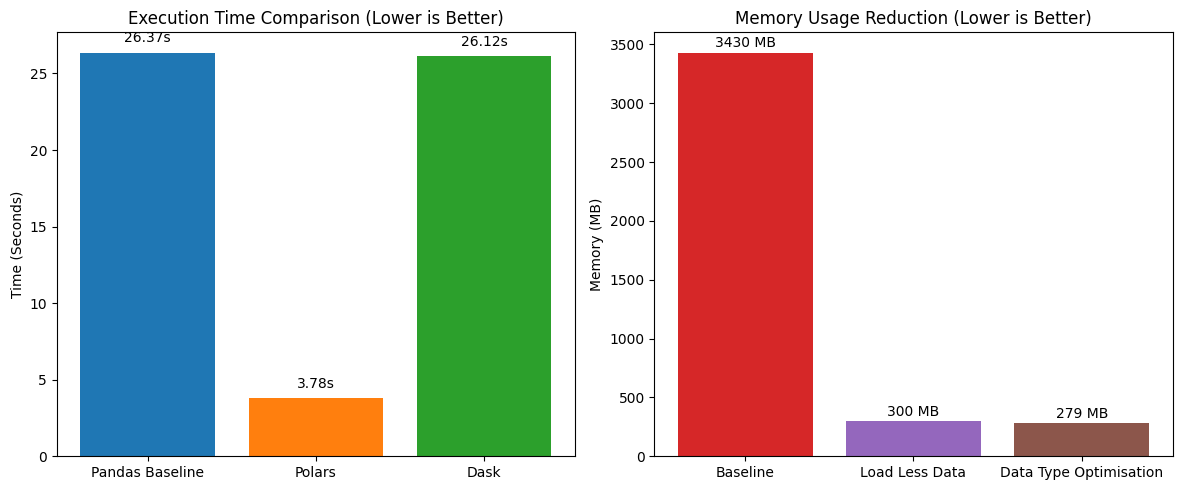

In [17]:
libraries = ['Pandas Baseline', 'Polars', 'Dask']
execution_times = [26.37, 3.78, 26.12]

memory_strategies = ['Baseline', 'Load Less Data', 'Data Type Optimisation']
memory_usage = [3430.50, 300.19, 279.18]

# --- 2. PLOT EXECUTION TIMES ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
bars = plt.bar(libraries, execution_times, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Execution Time Comparison (Lower is Better)')
plt.ylabel('Time (Seconds)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}s', ha='center', va='bottom')

# --- 3. PLOT MEMORY USAGE ---
plt.subplot(1, 2, 2)
bars2 = plt.bar(memory_strategies, memory_usage, color=['#d62728', '#9467bd', '#8c564b'])
plt.title('Memory Usage Reduction (Lower is Better)')
plt.ylabel('Memory (MB)')
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20, f'{yval:.0f} MB', ha='center', va='bottom')

plt.tight_layout()
plt.show()